This notebook/scripts runs the nuclei segmentation pipeline for 3D images.

In [1]:
import argparse
import os
import pathlib
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import skimage
import tifffile
import tomli
import torch
from cellpose import models
from image_analysis_3D.featurization_utils.resource_profiling_util import (
    start_profiling,
    stop_profiling,
)
from image_analysis_3D.file_utils.arg_parsing_utils import (
    check_for_missing_args,
    parse_args,
)
from image_analysis_3D.file_utils.file_reading import (
    find_files_available,
    read_in_channels,
    read_zstack_image,
)
from image_analysis_3D.file_utils.notebook_init_utils import (
    bandicoot_check,
    init_notebook,
)
from image_analysis_3D.file_utils.read_in_channel_mapping import *
from image_analysis_3D.segmentation_utils.general_segmentation_utils import *
from image_analysis_3D.segmentation_utils.nuclei_segmentation import *
from image_analysis_3D.segmentation_utils.segmentation_decoupling import *
from skimage.filters import sobel
from skimage.segmentation import relabel_sequential

In [2]:
start_time, start_mem = start_profiling()

In [3]:
root_dir, in_notebook = init_notebook()

image_base_dir = bandicoot_check(
    pathlib.Path(os.path.expanduser("~/mnt/bandicoot")).resolve(), root_dir
)

In [4]:
if not in_notebook:
    args = parse_args()
    clip_limit = args["clip_limit"]
    well_fov = args["well_fov"]
    patient = args["patient"]
    input_subparent_name = args["input_subparent_name"]
    mask_subparent_name = args["mask_subparent_name"]
    check_for_missing_args(
        well_fov=well_fov,
        patient=patient,
        clip_limit=clip_limit,
        input_subparent_name=input_subparent_name,
        mask_subparent_name=mask_subparent_name,
    )
else:
    print("Running in a notebook")
    patient = "NF0014_T2"
    well_fov = "C5-6"
    window_size = 3
    clip_limit = 0.01
    input_subparent_name = "zstack_images"
    mask_subparent_name = "segmentation_masks"


input_dir = pathlib.Path(
    f"{image_base_dir}/data/{patient}/{input_subparent_name}/{well_fov}"
).resolve(strict=True)
mask_path = pathlib.Path(
    f"{image_base_dir}/data/{patient}/{mask_subparent_name}/{well_fov}"
).resolve()
mask_path.mkdir(exist_ok=True, parents=True)
channel_dict = retrieve_channel_mapping(f"{root_dir}/config/channel_mapping.toml")

Running in a notebook


In [5]:
return_dict = read_in_channels(
    find_files_available(input_dir),
    channel_dict=channel_dict,
    channels_to_read=["DNA"],
)


nuclei_raw = return_dict["DNA"]
# run clip_limit here
nuclei = skimage.exposure.equalize_adapthist(
    nuclei_raw, clip_limit=clip_limit, kernel_size=None
)
del nuclei_raw

## Nuclei Segmentation

In [6]:
nuclei_image_shape = nuclei.shape
nuclei_masks = np.array(  # convert to array
    list(  # send to list
        decouple_masks(  # 4. decouple masks
            reverse_sliding_window_max_projection(  # 3. reverse sliding window
                segmentaion_on_two_D(  # 2. segment on 2D
                    sliding_window_two_point_five_D(  # 1. run sliding window
                        image_stack=nuclei, window_size=3
                    )
                ),
                window_size=3,
                original_z_slice_count=nuclei_image_shape[0],
            ),
            original_img_shape=nuclei_image_shape,
            distance_threshold=10,
        ).values()
    )
)

100%|██████████| 19/19 [00:03<00:00,  4.76it/s]


## remove small masks in each slice

In [7]:
# Remove small objects while preserving label IDs
# we avoid using the built-in skimage remove small objects function to preserve label IDs
for zslice in range(nuclei_masks.shape[0]):
    props = skimage.measure.regionprops(nuclei_masks[zslice])

    # Remove objects smaller than threshold
    for prop in props:
        if prop.area < 250:  # ~15x15 pixel region for nuclei
            # removed prior to the stitching.
            # which is a reasonable size threshold for nuclei
            nuclei_masks[zslice] = np.where(
                nuclei_masks[zslice] == prop.label, 0, nuclei_masks[zslice]
            )

In [8]:
nuclei_mask, diag = object_stitching_and_relation(
    input_masks=nuclei_masks,
    max_match_distance=100,
    max_trajectory_length=15,  # 15 slice length (15 = 15 um)
    verbose=False,
)

## Remove edge objects

In [9]:
nuclei_mask = clean_border_objects(nuclei_mask, border_width=5)

## relabel the nuclei

In [10]:
nuclei_mask, _, _ = relabel_sequential(nuclei_mask)

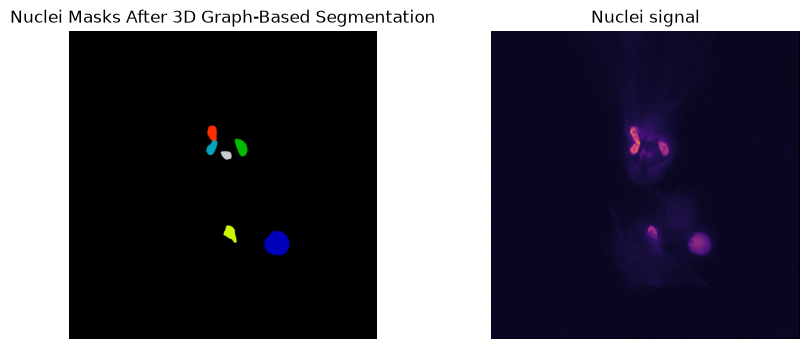

In [11]:
if in_notebook:
    z = nuclei_masks.shape[0] // 4
    plt.figure(figsize=(10, 4))
    plt.subplot(121)
    plt.imshow(nuclei_mask[z], cmap="nipy_spectral")
    plt.title("Nuclei Masks After 3D Graph-Based Segmentation")
    plt.axis("off")
    plt.subplot(122)
    plt.imshow(nuclei[z], cmap="magma")
    plt.axis("off")
    plt.title("Nuclei signal")
    plt.show()

## Save the segmented masks

In [12]:
nuclei_mask_output = pathlib.Path(f"{mask_path}/nuclei_mask.tiff")
tifffile.imwrite(nuclei_mask_output, nuclei_mask)

In [13]:
stop_profiling(
    start_time=start_time,
    start_mem=start_mem,
    feature_type="Segmentation",
    well_fov=well_fov,
    patient_id=patient,
    channel="NoChannel",
    compartment="nuclei",
    CPU_GPU="GPU",
    output_file_dir=pathlib.Path(
        f"{image_base_dir}/data/{patient}/segmentation_masks/run_stats/{well_fov}_nuclei_segmentation.parquet"
    ),
)


        Memory and time profiling for the run:
        Patient ID: NF0014_T2
        Well and FOV: C5-6
        Feature type: Segmentation
        CPU/GPU: GPU
        Peak memory (tracemalloc): 2805.82 MB
        Current memory (tracemalloc): 932.12 MB
        RSS at end: 3226.75 MB
        Time elapsed:
        --- 51.45 seconds ---
        --- 0.86 minutes ---
        --- 0.01 hours ---
    


True

Note for an image of the pixel size (20, 1500, 1500) (Z,Y,X). 
This runs in under 1 minute on a GPU + CPU and uses less than 3GB of RAM.

In [14]:
np.unique(nuclei_mask)

array([0, 1, 2, 3, 4, 5, 6, 7, 8], dtype=uint16)